# 修改旧图测试 - 2026-04-21

测试5项图表修改：
1. 标准差椭圆线宽×2 + 说明文档
2. 平衡度图例修改 + 街道级平衡度
3. 人数分布图8级分类
4. TAZ空白底图
5. 四格局人流箱线图（双子图）

In [1]:
import sys
from pathlib import Path

project_root = Path(r"E:\00_Commute_Scenario_Research")
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import geopandas as gpd

# Force fiona engine to avoid pyogrio/PROJ runtime errors in this environment.
gpd.options.io_engine = "fiona"

from src import (
    STATIC_CSV, SHP_PATH, get_result_path, logger,
 )
from src.data_prep import load_fence
from src.metrics_eval import compute_balance_ratio, compute_street_balance_ratio
from src.visualization import create_choropleth_map, create_blank_taz_map, create_street_choropleth
from src.geo_excu import plot_std_ellipse, compute_std_ellipse

print("模块加载完成")

模块加载完成


## 1. 标准差椭圆线宽×2 + 说明文档

In [2]:
fence = load_fence(SHP_PATH)
output_section = '3.Situation_Diagnosis/3.1Holistic_Diagnosis/3.1.1Static_Stats'

# 生成v3版本（线宽5.0）
out_fig = get_result_path(output_section, 'star_标准差椭圆_v3.png')
plot_std_ellipse(fence, STATIC_CSV, out_fig)

# 生成说明文档
df_static = pd.read_csv(STATIC_CSV, encoding='utf-8-sig')
fence_pts = fence[['taz', 'center_x', 'center_y']].copy()
fence_pts['taz'] = fence_pts['taz'].astype(int)
df_static['taz'] = df_static['taz'].astype(int)

df_home = df_static[df_static['人口类型'] == 'home'].merge(fence_pts, on='taz', how='inner')
df_work = df_static[df_static['人口类型'] == 'work'].merge(fence_pts, on='taz', how='inner')

from pyproj import Transformer
from src.config import CRS_UTM
transformer = Transformer.from_crs('EPSG:4326', CRS_UTM, always_xy=True)

def _to_proj(df):
    x, y = transformer.transform(df['center_x'].values, df['center_y'].values)
    return np.column_stack([x, y]), df['人数'].values

coords_home, w_home = _to_proj(df_home)
coords_work, w_work = _to_proj(df_work)

ell_home = compute_std_ellipse(coords_home, w_home)
ell_work = compute_std_ellipse(coords_work, w_work)

# 计算椭圆面积
area_home = np.pi * ell_home['semi_major'] * ell_home['semi_minor'] / 1e6  # km²
area_work = np.pi * ell_work['semi_major'] * ell_work['semi_minor'] / 1e6

# 重合度分析（中心距离 / 平均半径）
center_dist = np.sqrt((ell_home['center_x'] - ell_work['center_x'])**2 + 
                      (ell_home['center_y'] - ell_work['center_y'])**2)
avg_radius = (ell_home['semi_major'] + ell_work['semi_major']) / 4
overlap_ratio = 1 - min(center_dist / avg_radius, 1.0)

doc_content = f"""# 标准差椭圆说明

## 椭圆参数

### 居住地（O端）
- 长半轴（semi_major）: {ell_home['semi_major']:.2f} 米
- 短半轴（semi_minor）: {ell_home['semi_minor']:.2f} 米
- 方向角（angle_deg）: {ell_home['angle_deg']:.2f}°
- 椭圆面积: {area_home:.2f} km²
- 中心坐标: ({ell_home['center_x']:.2f}, {ell_home['center_y']:.2f})

### 工作地（D端）
- 长半轴（semi_major）: {ell_work['semi_major']:.2f} 米
- 短半轴（semi_minor）: {ell_work['semi_minor']:.2f} 米
- 方向角（angle_deg）: {ell_work['angle_deg']:.2f}°
- 椭圆面积: {area_work:.2f} km²
- 中心坐标: ({ell_work['center_x']:.2f}, {ell_work['center_y']:.2f})

## 算法说明

标准差椭圆基于加权协方差矩阵计算，权重为各TAZ的人口数。椭圆的长短轴由协方差矩阵的特征值决定，方向由特征向量决定。

本图采用2倍标准差椭圆，理论上囊括约95%的人口分布（假设正态分布）。

## 方向解读

- 居住地椭圆方向角 {ell_home['angle_deg']:.1f}°：{'西北-东南' if -45 <= ell_home['angle_deg'] <= 45 else '东北-西南' if 45 < ell_home['angle_deg'] <= 135 else '西南-东北' if -135 <= ell_home['angle_deg'] < -45 else '南北'}方向
- 工作地椭圆方向角 {ell_work['angle_deg']:.1f}°：{'西北-东南' if -45 <= ell_work['angle_deg'] <= 45 else '东北-西南' if 45 < ell_work['angle_deg'] <= 135 else '西南-东北' if -135 <= ell_work['angle_deg'] < -45 else '南北'}方向

## 重合度分析

- 两椭圆中心距离: {center_dist:.2f} 米
- 重合度估计: {overlap_ratio*100:.1f}%
- 解读: {'职住空间高度重合' if overlap_ratio > 0.7 else '职住空间部分重合' if overlap_ratio > 0.4 else '职住空间分离明显'}

## 与其他城市对比

（需补充参考数据）
"""

doc_path = get_result_path(output_section, 'star_标准差椭圆_说明.md')
doc_path.write_text(doc_content, encoding='utf-8')
print(f"说明文档已保存: {doc_path}")

2026-04-21 21:56:37,210 - ERROR - PROJ: proj_identify: C:\Users\Administrator\.conda\envs\job_housing\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-21 21:56:37,289 - ERROR - PROJ: proj_identify: C:\Users\Administrator\.conda\envs\job_housing\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-21 21:56:39,056 - INFO - 地理围栏原始行数: 4817, unique taz: 2427, CRS=GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
2026-04-21 21:56:41,023 - INFO - dissolve后行数: 2427
2026-04-21 21:56:46,408 - INFO - 标准差椭圆图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.1Static_Stats\star_标准差

说明文档已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.1Static_Stats\star_标准差椭圆_说明.md


## 2. 平衡度图例修改 + 街道级平衡度

2026-04-21 21:56:46,775 - INFO - compute_balance_ratio: 2427 TAZ, 平衡度均值=4.131, 中位数=1.280
2026-04-21 21:56:46,776 - INFO - 开始执行: create_choropleth_map
2026-04-21 21:56:54,817 - INFO - 地图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.1Static_Stats\star_平衡度分布图_v3.png
2026-04-21 21:56:54,856 - INFO - 统计信息已保存: E:\00_Commute_Scenario_Research\results\create_choropleth_map_stats.csv
2026-04-21 21:56:54,867 - INFO - 完成: create_choropleth_map, 耗时: 8.09秒
2026-04-21 21:56:54,914 - ERROR - PROJ: proj_identify: C:\Users\Administrator\.conda\envs\job_housing\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-21 21:56:54,965 - ERROR - PROJ: proj_identify: C:\Users\Administrator\.conda\envs\job_housing\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-04-2

平衡度图表已生成


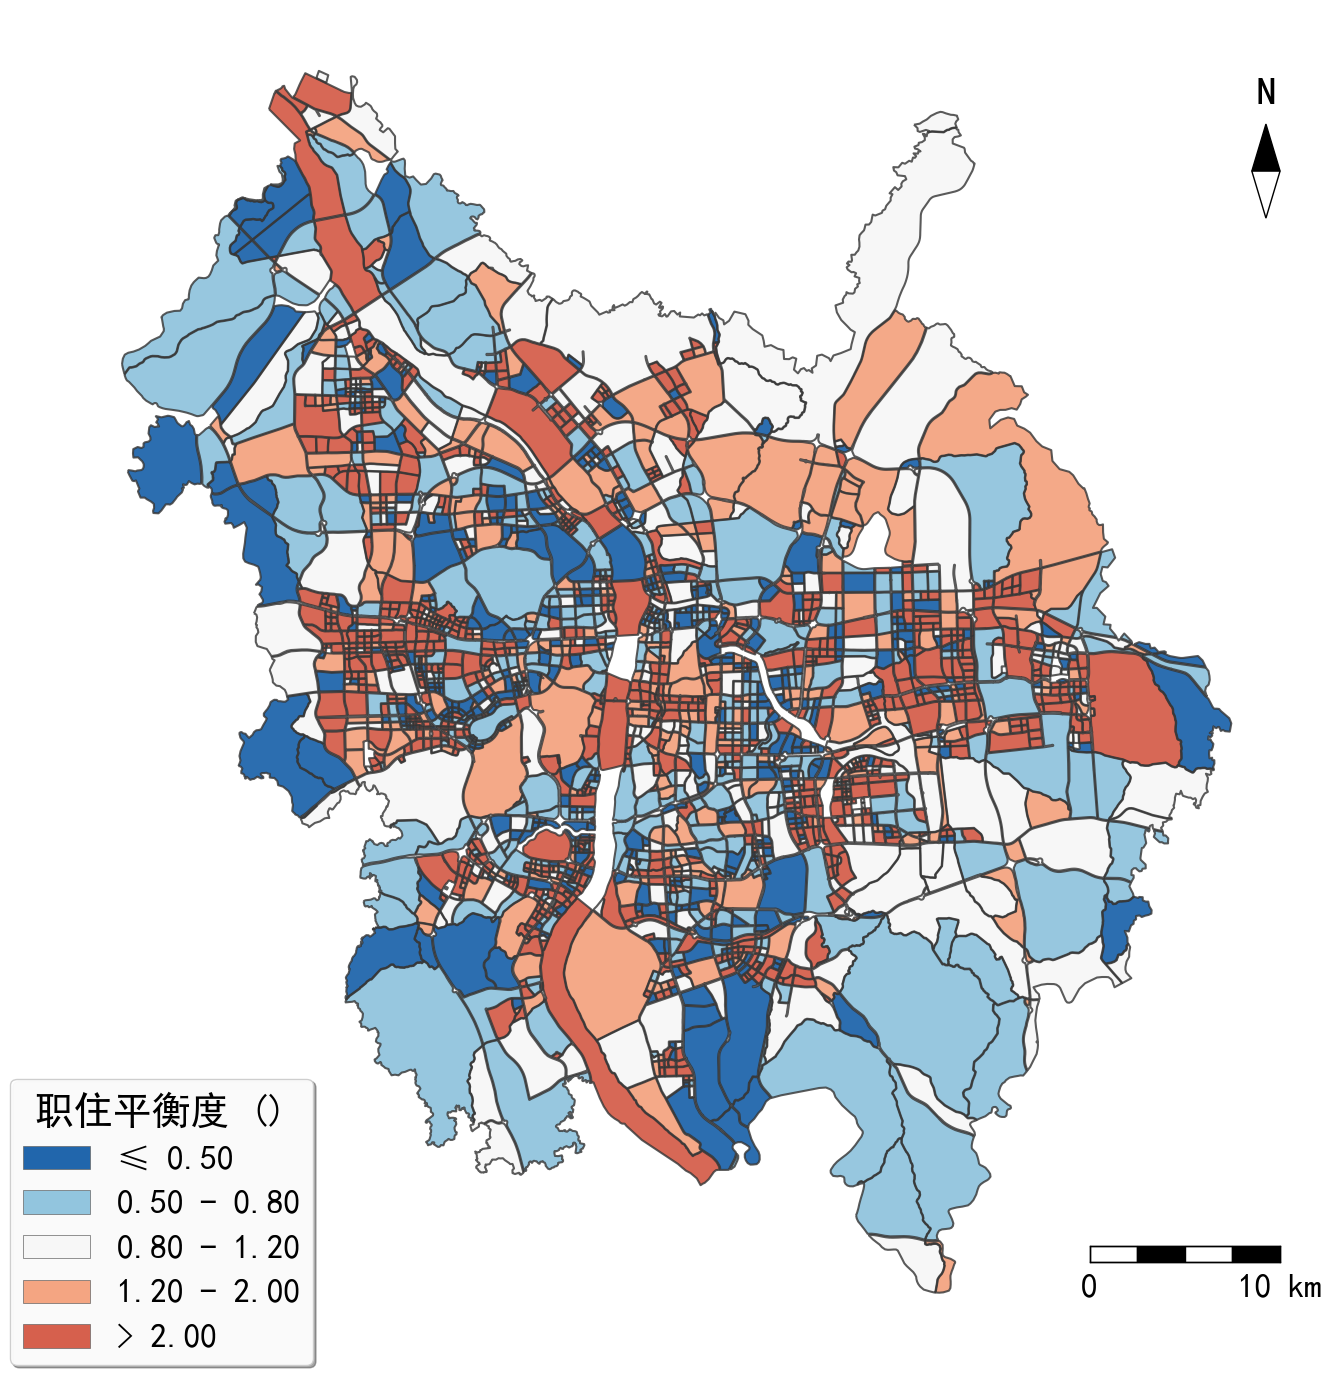

In [3]:
# TAZ级平衡度（v3版本，图例无\"倍\"字）
gdf_balance = compute_balance_ratio(STATIC_CSV, fence)
out_fig = get_result_path(output_section, 'star_平衡度分布图_v3.png')
create_choropleth_map(gdf_balance, fence, '平衡度', 'balance_ratio', out_fig)

# 街道级平衡度
STREET_SHP = Path(r"F:\02_250910_Commute\02-原始数据\[最终矫正版]街道乡镇边界\31\内部边界修改.shp")
gdf_street_balance = compute_street_balance_ratio(STATIC_CSV, fence, STREET_SHP)

out_fig_street = get_result_path(output_section, 'star_平衡度分布图_街道_v3.png')
fence_taz = fence.copy()
if fence_taz.crs != gdf_street_balance.crs:
    fence_taz = fence_taz.to_crs(gdf_street_balance.crs)
create_street_choropleth(gdf_street_balance, fence_taz, '平衡度', 'balance_ratio', out_fig_street)

print("平衡度图表已生成")

## 3. 人数分布图8级分类

2026-04-21 21:57:08,266 - INFO - 开始执行: compute_taz_indicators
2026-04-21 21:57:08,676 - INFO - 统计信息已保存: E:\00_Commute_Scenario_Research\results\compute_taz_indicators_stats.csv
2026-04-21 21:57:08,680 - INFO - 完成: compute_taz_indicators, 耗时: 0.41秒
2026-04-21 21:57:08,683 - INFO - 开始执行: create_choropleth_map
2026-04-21 21:57:17,596 - INFO - 地图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.1Static_Stats\star_人数分布_O端_v3.png
2026-04-21 21:57:17,603 - INFO - 统计信息已保存: E:\00_Commute_Scenario_Research\results\create_choropleth_map_stats.csv
2026-04-21 21:57:17,609 - INFO - 完成: create_choropleth_map, 耗时: 8.93秒
2026-04-21 21:57:17,649 - INFO - 开始执行: create_choropleth_map
2026-04-21 21:57:25,907 - INFO - 地图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.1Static_Stats\star_人数分布_D端_v3.png
2026-04-21 21:57:25,917 - INFO - 统计信息已保存: E:\00_Commute_Scenario_Research\results\create_choropleth_map_stats.csv
2026-04-

人数分布图（8级）已生成


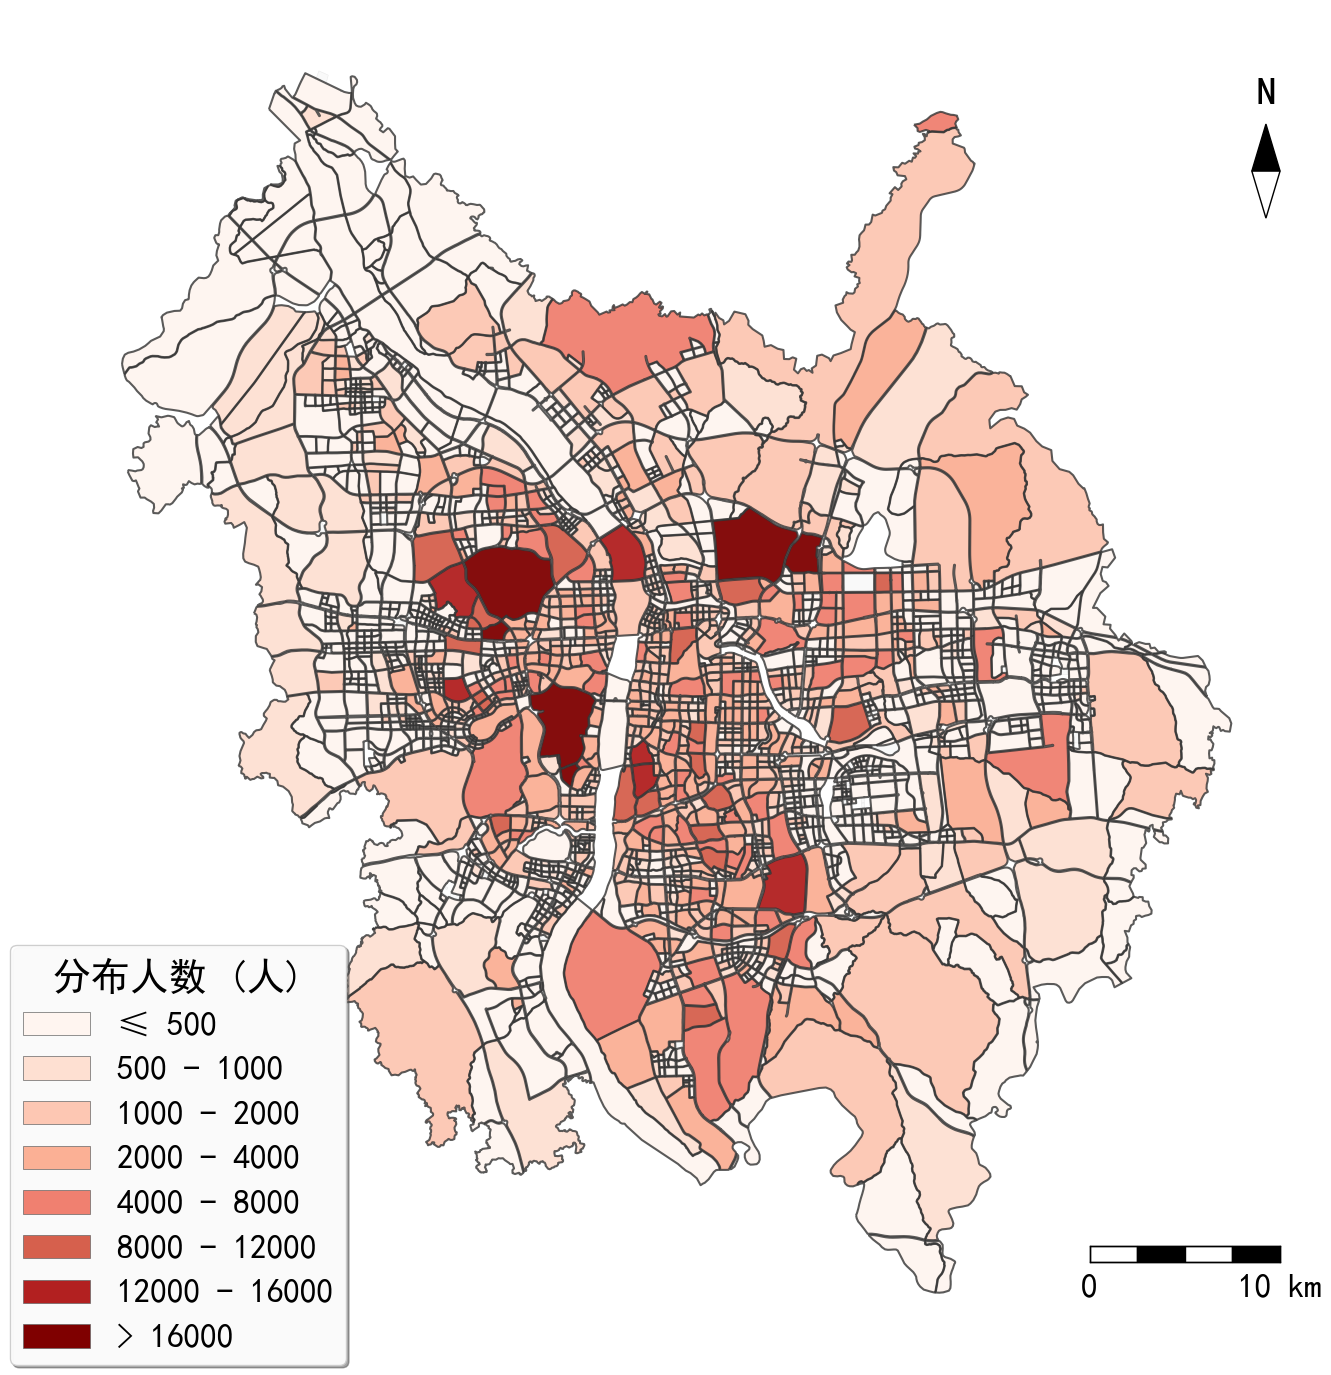

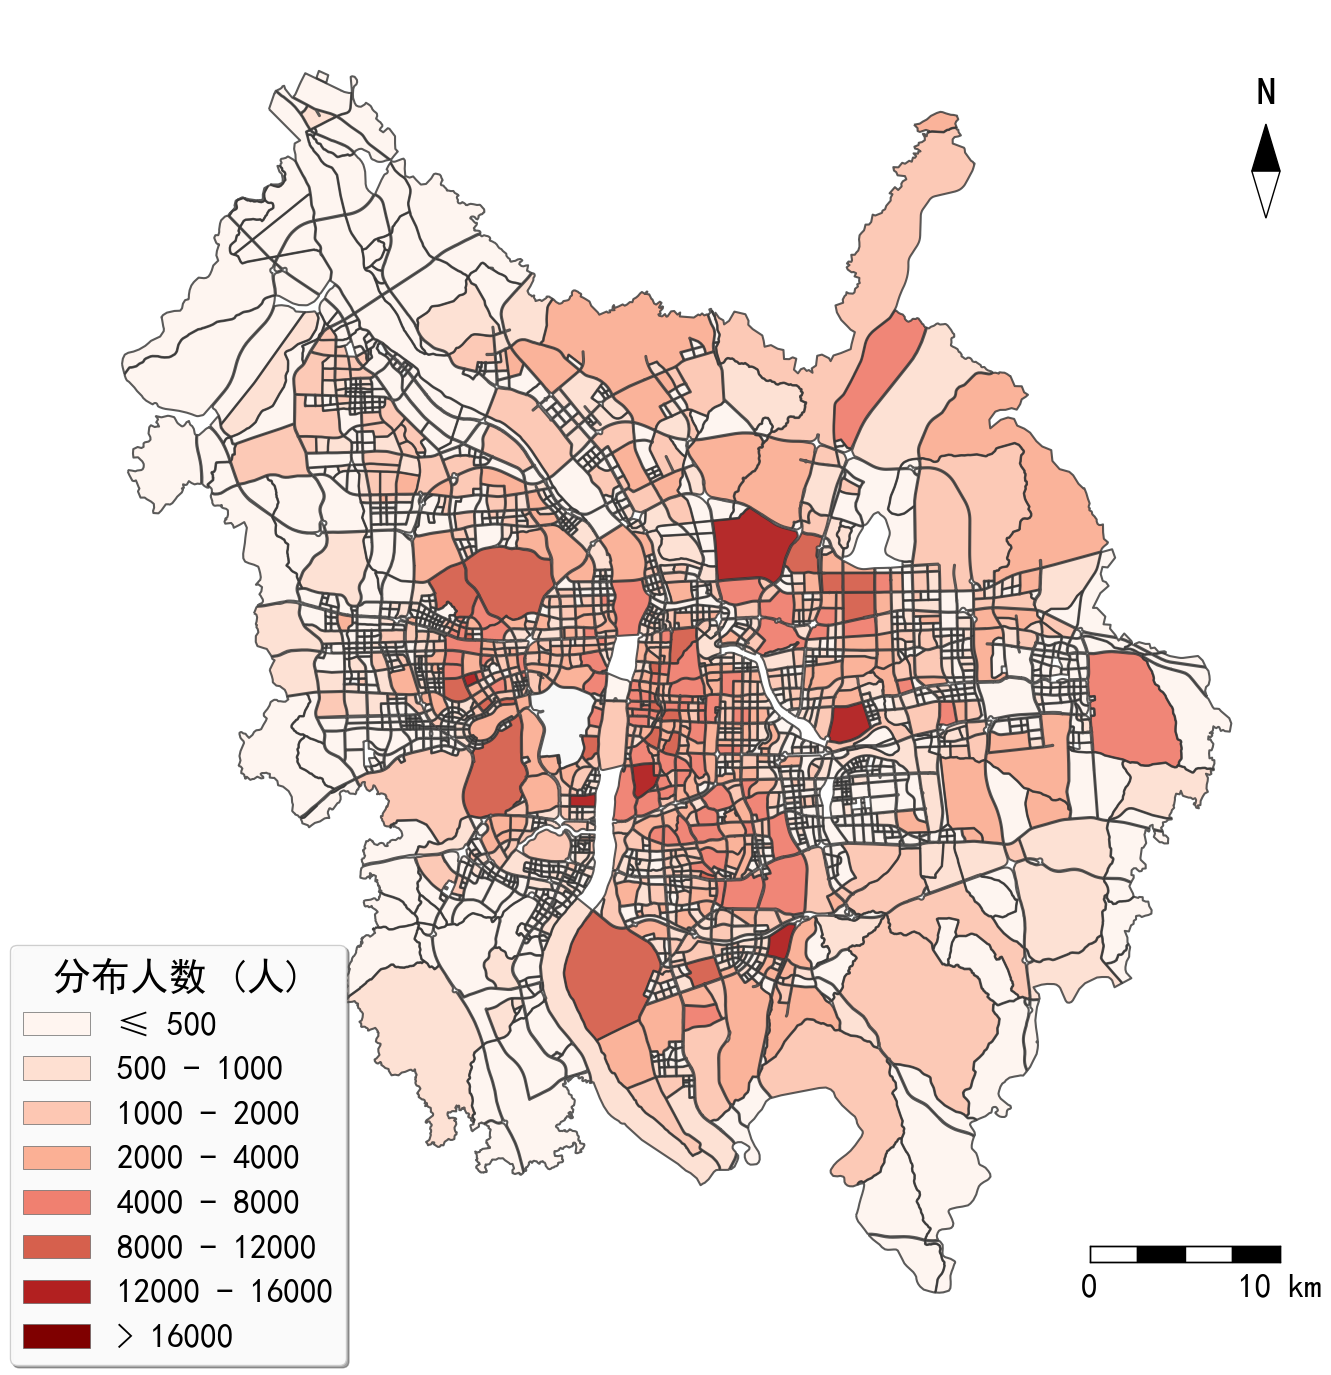

In [4]:
# 读取实际格局数据
ACTUAL_CSV = project_root / 'results' / '1.Data_Preprocess' / '实际格局-统一结构.csv'
df_actual = pd.read_csv(ACTUAL_CSV, encoding='utf-8-sig')

# 统一列名
col_map = {}
for c in df_actual.columns:
    cl = c.lower()
    if cl in ('htaz', 'o', 'origin'):
        col_map[c] = 'o'
    elif cl in ('jtaz', 'd', 'dest', 'destination'):
        col_map[c] = 'd'
    elif cl in ('flow', '人数', 'count', 'trips'):
        col_map[c] = '人数'
    elif cl in ('distance', 'distance_m', 'dist'):
        col_map[c] = 'distance'

df_actual = df_actual.rename(columns=col_map)[['o', 'd', '人数', 'distance']].copy()
df_actual['o'] = df_actual['o'].astype(int)
df_actual['d'] = df_actual['d'].astype(int)

from src.metrics_eval import compute_taz_indicators

# O端人数分布
gdf_o = compute_taz_indicators(df_actual, fence)
out_o = get_result_path(output_section, 'star_人数分布_O端_v3.png')
create_choropleth_map(gdf_o, fence, '总通勤人数', 'static_people', out_o)

# D端人数分布
d_total = (df_actual.groupby('d')['人数'].sum()
           .reset_index()
           .rename(columns={'d': 'taz', '人数': '总通勤人数'}))
fence_copy = fence[['taz', 'geometry']].copy()
fence_copy['taz'] = fence_copy['taz'].astype(int)
d_total['taz'] = d_total['taz'].astype(int)
gdf_d = gpd.GeoDataFrame(
    fence_copy.merge(d_total, on='taz', how='left'),
    geometry='geometry', crs=fence.crs
)
out_d = get_result_path(output_section, 'star_人数分布_D端_v3.png')
create_choropleth_map(gdf_d, fence, '总通勤人数', 'static_people', out_d)

print("人数分布图（8级）已生成")

## 4. TAZ空白底图

In [5]:
out_blank = get_result_path(output_section, 'star_TAZ研究单元底图.png')
create_blank_taz_map(fence, out_blank)
print("TAZ空白底图已生成")

2026-04-21 21:57:52,894 - INFO - 空白TAZ底图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.1Static_Stats\star_TAZ研究单元底图.png


TAZ空白底图已生成


## 5. 四格局人流箱线图（双子图）

In [6]:
# 加载四个格局数据
IDEAL_CSV = project_root / 'results' / '2.Pattern_Computation' / '2.1Theoretical_Pattern' / '理想格局-统一结构-0414.csv'
df_ideal = pd.read_csv(IDEAL_CSV, encoding='utf-8-sig')
col_map_ideal = {}
for c in df_ideal.columns:
    cl = c.lower()
    if cl in ('htaz', 'o', 'origin'):
        col_map_ideal[c] = 'o'
    elif cl in ('jtaz', 'd', 'dest', 'destination'):
        col_map_ideal[c] = 'd'
    elif cl in ('flow', '人数', 'count', 'trips'):
        col_map_ideal[c] = '人数'
    elif cl in ('distance', 'distance_m', 'dist'):
        col_map_ideal[c] = 'distance'
df_ideal = df_ideal.rename(columns=col_map_ideal)[['o', 'd', '人数', 'distance']].copy()

BASELINE_CSV = project_root / 'results' / '2.Pattern_Computation' / '2.4Baseline_Int' / 'star_baseline_int.csv'
df_baseline = pd.read_csv(BASELINE_CSV, encoding='utf-8-sig')

RANDOM_CSV = project_root / 'results' / '2.Pattern_Computation' / '2.5Random_Int' / 'star_random_int.csv'
df_random = pd.read_csv(RANDOM_CSV, encoding='utf-8-sig')

# 调用evaluation模块的函数（使用绝对路径，避免相对路径受cwd影响）
evaluation_nb = project_root / 'notebooks' / 'sub_pipeline' / 'evaluation.ipynb'
if not evaluation_nb.exists():
    raise FileNotFoundError(f'未找到评估模块文件: {evaluation_nb}')
get_ipython().run_line_magic('run', f'-i "{evaluation_nb.as_posix()}"')

output_section_pattern = '3.Situation_Diagnosis/3.1Holistic_Diagnosis/3.1.3Pattern_Comparison'
eval_V98_flow_boxplot(df_actual, df_ideal, df_baseline, df_random, output_section_pattern, save_fig=True)

print("四格局人流箱线图（双子图）已生成")

2026-04-21 21:58:06,092 - INFO - 人流箱线图（双子图）已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.3Pattern_Comparison\star_格局对比_人流箱线图_四格局_v3.png


四格局人流箱线图（双子图）已生成


## 验证清单

In [ ]:
print("\n=" * 40)
print("验证清单")
print("=" * 40)

checks = [
    ('star_标准差椭圆_v3.png', '线宽为5.0'),
    ('star_标准差椭圆_说明.md', '包含semi_major/semi_minor数值（米）'),
    ('star_平衡度分布图_v3.png', '图例为\"职住平衡度\"（无\"倍\"字）'),
    ('star_平衡度分布图_街道_v3.png', '街道级平衡度图存在'),
    ('star_人数分布_O端_v3.png', '8级分类'),
    ('star_人数分布_D端_v3.png', '8级分类'),
    ('star_TAZ研究单元底图.png', '只有边界线、指北针、比例尺'),
]

for filename, desc in checks:
    path = get_result_path(output_section, filename)
    exists = path.exists()
    print(f"{'✓' if exists else '✗'} {filename}: {desc}")

# 箱线图单独检查
boxplot_path = get_result_path(output_section_pattern, 'star_格局对比_人流箱线图_四格局_v3.png')
print(f"{'✓' if boxplot_path.exists() else '✗'} star_格局对比_人流箱线图_四格局_v3.png: 双子图（左0-200，右对数轴）")

print("\n所有修改完成！")